In [1]:
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from src.utils import align_tracked_particle_across_layers
from src.jax_resnet.model import init_params

In [3]:
DATASET = "mnist"  # or "mnist", "cifar10"
mask_distribution = "centered_gaussian" #"rescaled_bernoulli"

In [4]:
if DATASET == "mnist":
    from mnist_config import (
        d_in, d_out, seed, N, X_train, Y_train, X_test, Y_test, 
        tau, n_steps, lr_in, lr_out, q, batch_size, 
        last_particle_single_source, eval_every, ACTIVATION, num_repetitions, LOOP_SEED,
        BASE_SETTING_STR
        )
elif DATASET == "cifar10":
    from cifar10_config import (
        d_in, d_out, seed, N, X_train, Y_train, X_test, Y_test, 
        tau, n_steps, lr_in, lr_out, q, batch_size, 
        last_particle_single_source, eval_every, ACTIVATION, num_repetitions, LOOP_SEED,
        BASE_SETTING_STR
    )

(800, 784) (800, 2) (200, 784) (200, 2)


In [5]:
D, L, M = 10, 4, 4

In [6]:
params0 = init_params(random.PRNGKey(seed + 44), d_in, d_out, D, L, M)
params0 = align_tracked_particle_across_layers(params0, particle_idx=-1)

In [7]:
import pickle

setting_str = f'L{L}_M{M}_D{D}' + BASE_SETTING_STR


with open(f'data/{DATASET}/{mask_distribution}/histories_gd_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    histories_gd = pickle.load(f)
with open(f'data/{DATASET}/{mask_distribution}/histories_do_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    histories_do = pickle.load(f)
with open(f'data/{DATASET}/{mask_distribution}/histories_ram_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    histories_ram = pickle.load(f)


In [8]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset, inset_axes

def plot_test_loss_compare_all_runs(show=True, xlim=None, ylim=None, eval_every=10, n_steps=None,
                                     zoom=None, zoom_loc='upper right', zoom_scale=2.5,
                                     zoom_ylim=None):
    """
    ...
    zoom : tuple (a, b) or None
        If given, adds an inset axes zoomed into the x-range (a, b).
    zoom_loc : str
        Location of the inset (matplotlib legend-style location string).
    zoom_scale : float
        Magnification factor of the inset relative to the main axes.
    zoom_ylim : tuple or None
        Optional explicit y-limits for the inset; otherwise auto-scaled to the data in (a, b).
    """
    run_specs = {
        'GD': histories_gd["gd"],
        'Dropout (independent)': histories_do["full_unit_dropout"],
        'RaM (independent)': histories_ram["full_unit_dropout"],
        'Dropout (width-shared)': histories_do["stochastic_depth"],
        'RaM (width-shared)': histories_ram["stochastic_depth"],
        'Dropout (depth-shared)': histories_do["single_source_M"],
        'RaM (depth-shared)': histories_ram["single_source_M"],
    }
    run_colors = {
        'GD': 'black',
        'Dropout (independent)': 'tab:blue',
        'RaM (independent)': 'tab:blue',
        'Dropout (width-shared)': 'tab:green',
        'RaM (width-shared)': 'tab:green',
        'Dropout (depth-shared)': 'tab:purple',
        'RaM (depth-shared)': 'tab:purple',
    }
    run_linestyles = {
        'GD': '-',
        'Dropout (independent)': '--',
        'RaM (independent)': '-',
        'Dropout (width-shared)': '--',
        'RaM (width-shared)': '-',
        'Dropout (depth-shared)': '--',
        'RaM (depth-shared)': '-',
    }

    num_points = len(histories_gd["gd"][0]['test_loss'])
    idx = np.arange(num_points)
    x_steps = idx * eval_every
    if n_steps is None:
        n_steps_local = globals().get('n_steps', None)
    else:
        n_steps_local = n_steps
    if n_steps_local is not None:
        if x_steps[-1] != (n_steps_local - 1):
            x_steps[-1] = n_steps_local - 1

    fig, ax = plt.subplots(figsize=(5, 4))

    # keep track of per-run mean/std so we can reuse them for the inset without recomputing
    run_data = {}

    for run_name, run_history in run_specs.items():
        values = np.stack([np.asarray(h['test_loss']) for h in run_history], axis=0)
        mean = values.mean(axis=0)
        std = values.std(axis=0)
        run_data[run_name] = (mean, std)
        color = run_colors[run_name]
        linestyle = run_linestyles[run_name]
        ax.plot(x_steps, mean, label=run_name, color=color, linestyle=linestyle)
        ax.fill_between(x_steps, mean - std, mean + std, color=color, alpha=0.1)

    ax.set_title('Test loss comparison')
    ax.set_xlabel('training step')
    ax.set_ylabel('test loss')

    if xlim is not None:
        left, right = xlim[0] if len(xlim) > 0 else None, xlim[1] if len(xlim) > 1 else None
        if left is None:
            left = x_steps[0]
        if right is None:
            right = x_steps[-1]
        ax.set_xlim(left, right)
    else:
        left, right = x_steps[0], x_steps[-1]
        ax.set_xlim(left, right)

    if ylim is not None:
        ax.set_ylim(ylim)
    ax.legend(fontsize=6)

    try:
        visible_steps = x_steps[(x_steps >= left) & (x_steps <= right)]
        n_ticks = min(10, len(visible_steps))
        if n_ticks > 1 and len(visible_steps) > 0:
            step = max(1, len(visible_steps) // n_ticks)
            ax.set_xticks(visible_steps[::step])
    except Exception:
        pass

    # --- Zoomed inset ---
    if zoom is not None:
        a, b = zoom
        #axins = zoomed_inset_axes(ax, zoom_scale, loc=zoom_loc)
        axins = inset_axes(
            ax,
            width="60%", height="60%",   # size of the inset relative to its bbox
            bbox_to_anchor=(1.1, 0.1, 1, 1),  # (x0, y0, width, height) in axes-fraction coords
            bbox_transform=ax.transAxes,
            loc='lower left',            # anchor point of the inset box itself
            borderpad=0,
        )

        mask = (x_steps >= a) & (x_steps <= b)
        for run_name in run_specs:
            mean, std = run_data[run_name]
            color = run_colors[run_name]
            linestyle = run_linestyles[run_name]
            axins.plot(x_steps[mask], mean[mask], color=color, linestyle=linestyle)
            axins.fill_between(x_steps[mask], (mean - std)[mask], (mean + std)[mask],
                                color=color, alpha=0.05)

        axins.set_xlim(a, b)
        if zoom_ylim is not None:
            axins.set_ylim(zoom_ylim)
        else:
            visible_vals = np.concatenate([run_data[r][0][mask] for r in run_specs])
            pad = 0.05 * (visible_vals.max() - visible_vals.min() + 1e-12)
            axins.set_ylim(visible_vals.min() - pad, visible_vals.max() + pad)

        axins.set_xticks([])
        axins.tick_params(labelsize=6)
        mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    fig.tight_layout()
    if show:
        plt.show()
    return fig

In [9]:
if DATASET == 'mnist':
    kwargs_plot = dict(xlim=(50, None), ylim=(0.315,0.38), eval_every=eval_every, n_steps=n_steps, zoom=(150, 200), zoom_loc='upper right', zoom_ylim=(0.32, 0.35))
elif DATASET == 'cifar10':
    kwargs_plot = dict(xlim=(0, None), ylim=(1.315,3.38), eval_every=eval_every, n_steps=n_steps, zoom=(15, 50), zoom_loc='upper right', zoom_ylim=(2.25, 2.35))

/var/folders/r6/y41vjmr92m187frtv8jcv8_80000gn/T/ipykernel_18133/2717313185.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


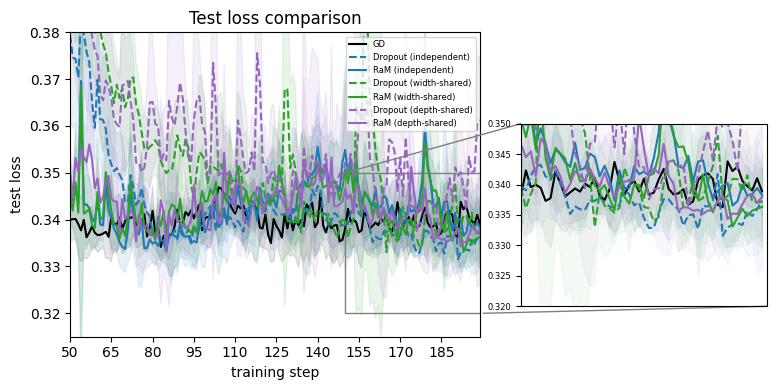

In [10]:
fig = plot_test_loss_compare_all_runs(**kwargs_plot)

In [ ]:
#fig.savefig(f"plots/{DATASET}/loss_ram_do_all_variants_N{N}_datasetL{L}M{M}.pdf", bbox_inches='tight')